In [3]:
import numpy as np
np.seterr(all="ignore")
import matplotlib.pyplot as plt
from SFstarred.cut2d import *
from SFstarred.save_and_read import read_hdf5_to_dict

In [4]:
star_cutouts = read_hdf5_to_dict("data_products/F160W/cut_out_F160W.hdf5")

In [35]:
stars = star_cutouts["data_cutout_norm"]#['data_cutout']
noisemaps = star_cutouts['sigma2_norm']#['sigma2']
stars.shape, noisemaps.shape

((4, 41, 41), (4, 41, 41))

In [36]:
noisemaps

array([[[0.0063161 , 0.00663291, 0.00675596, ..., 0.00683106,
         0.00733196, 0.0063161 ],
        [0.0063161 , 0.00703915, 0.00700651, ..., 0.00691338,
         0.0063161 , 0.0063161 ],
        [0.0063161 , 0.00655372, 0.00700735, ..., 0.00637908,
         0.00640574, 0.00718419],
        ...,
        [0.00637266, 0.0063161 , 0.00660325, ..., 0.0063161 ,
         0.0063161 , 0.00636421],
        [0.00683386, 0.00655041, 0.0068127 , ..., 0.0063161 ,
         0.0063161 , 0.00683536],
        [0.0063161 , 0.00640379, 0.0063161 , ..., 0.0063161 ,
         0.0063161 , 0.0063161 ]],

       [[0.00626612, 0.00630522, 0.00626612, ..., 0.00690529,
         0.00626612, 0.00626612],
        [0.00626612, 0.00626612, 0.00626612, ..., 0.00674573,
         0.00626612, 0.00626612],
        [0.00628302, 0.00626612, 0.00626612, ..., 0.00937544,
         0.00626612, 0.00626612],
        ...,
        [0.00648531, 0.00626612, 0.00626612, ..., 0.00639257,
         0.00630498, 0.00626612],
        [0.0

In [37]:
np.median(stars[0]),np.median(noisemaps[0])

(np.float64(0.07584666534217338), np.float64(0.006936881158588476))

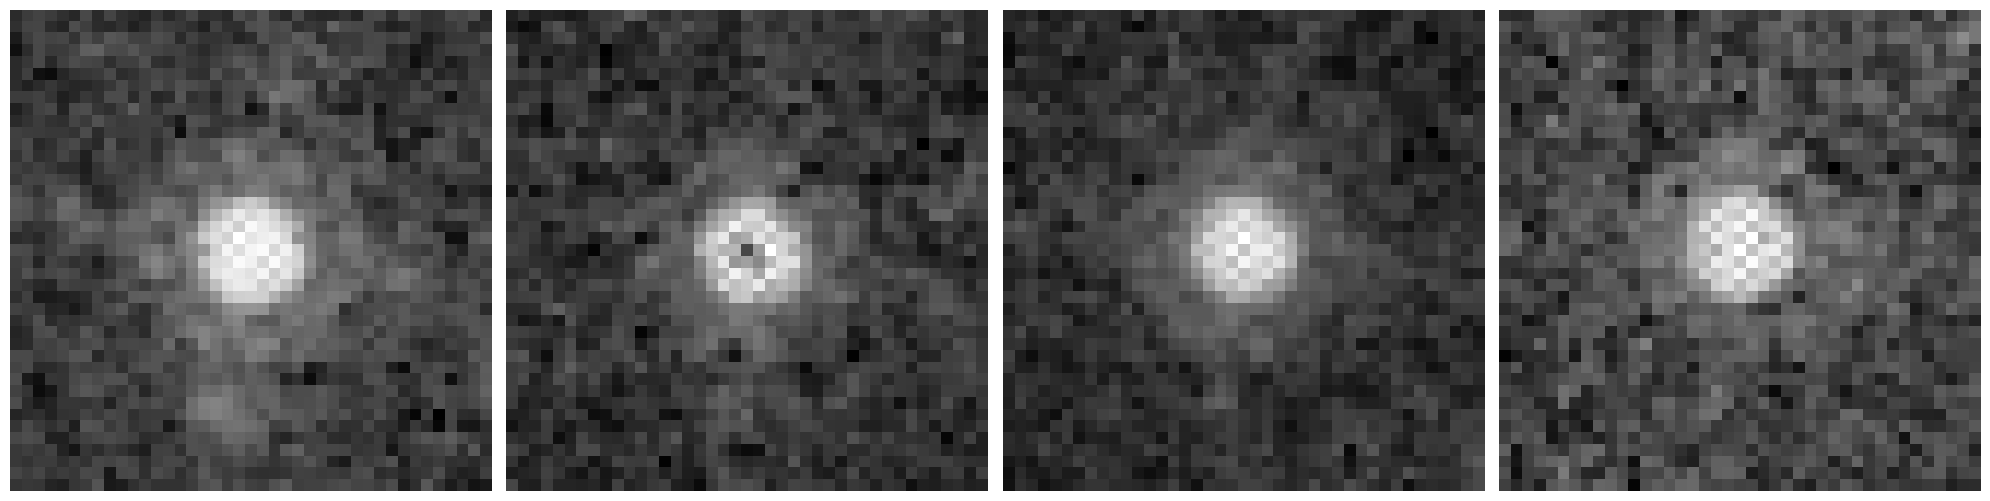

In [38]:
fig, axs = plt.subplots(1,4, figsize=(20,20))
for ax, star, noisemap in zip(axs, stars, noisemaps):
    ax.imshow(star/noisemap, cmap='gray'); ax.axis('off')
plt.tight_layout()

In [56]:
from starred.procedures import build_psf

result = build_psf(stars, noisemaps, subsampling_factor=2)
# result is a dictionary with the different components that can be useful,
# see the available entries:
result.keys()

optax.adabelief: 100%|██████████| 2000/2000 [00:35<00:00, 55.84it/s]


dict_keys(['model_instance', 'kwargs_psf', 'narrow_psf', 'full_psf', 'numerical_psf', 'moffat', 'models', 'residuals', 'analytical_optimizer_extra_fields', 'adabelief_extra_fields', 'chi2', 'chi2_per_stamp'])

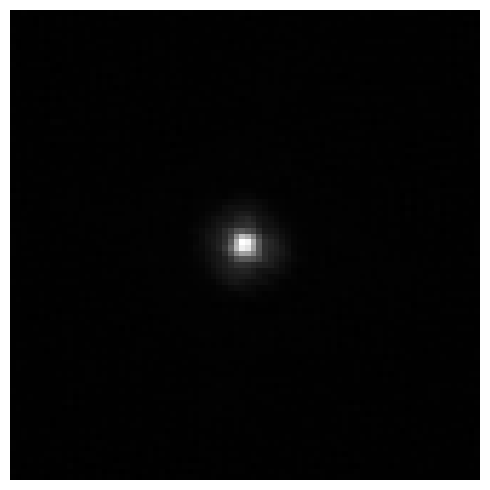

In [40]:
full_psf = result['full_psf']
plt.figure(figsize=(5,5))
plt.imshow(full_psf, cmap='gray')
plt.axis('off')
plt.tight_layout(); plt.show()

In [12]:
narrow_psfs = []
#for star, noisemap in zip(stars, noisemaps):
narrow = build_psf(stars, noisemaps, subsampling_factor=2)['narrow_psf']
narrow_psfs.append(narrow)
np.save('data_products/F160W/narrow_psfs.npy', narrow_psfs)

optax.adabelief: 100%|██████████| 2000/2000 [00:34<00:00, 57.80it/s] 


In [13]:
narrow_psfs = np.load('data_products/F160W/narrow_psfs.npy')

In [14]:
narrow_psfs

array([[[-1.7964526e-04,  1.6861793e-04,  1.6083688e-04, ...,
          2.3373222e-04, -1.8185041e-03,  7.6135943e-06],
        [ 4.0849159e-06,  1.9356994e-04, -4.8002481e-04, ...,
          9.5678179e-04,  1.8968044e-03,  4.1747821e-04],
        [-4.5826394e-04, -1.2052394e-05, -5.0925632e-04, ...,
         -1.9954634e-03, -4.9684761e-04, -1.6180605e-03],
        ...,
        [-6.6665321e-04, -1.3826144e-04, -7.3982397e-04, ...,
          2.2534255e-04,  5.9364841e-04,  7.8667377e-05],
        [ 8.2488213e-04,  1.2782153e-04, -9.4319119e-05, ...,
          1.2504515e-04, -3.6327849e-04, -4.9969193e-04],
        [ 8.3115192e-06, -5.8587245e-04, -1.2829171e-04, ...,
          1.9316086e-04, -7.2626641e-04,  1.0719191e-03]]],
      shape=(1, 82, 82), dtype=float32)

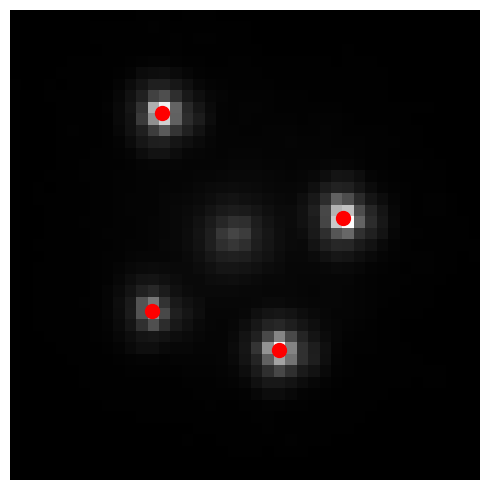

In [41]:
plt.figure(figsize=(5,5))
plt.imshow(star_cutouts["system_cut_out"], cmap='gray')
images_names = ["A","B","C","D"]
pt_sources = {}
for n,i in enumerate(star_cutouts["image_positions"]):
    pt_sources[images_names[n]] = i
    plt.scatter(*i,c="red",s=100)
plt.axis('off')
plt.tight_layout(); plt.show()

In [42]:
#object = np.load('data/object.npy', allow_pickle=True).item()
data = star_cutouts['system_cut_out'][None,:]
noisemaps = 1/ np.sqrt(star_cutouts['weights_system_cut_out'][None,:]) 
data.shape, noisemaps.shape

((1, 41, 41), (1, 41, 41))

In [17]:
np.median(data[0]),np.median(noisemaps[0])

(np.float64(0.19296854734420776), np.float64(0.02816104658400657))

In [43]:
im_size = data.shape[1]
offset = (im_size-1) / 2.
# while we're at it extract the x and y positions separately
xs = np.array([pt_sources[name][0] for name in 'ABCD']) - offset
ys = np.array([pt_sources[name][1] for name in 'ABCD']) - offset
brightnesses = len(data) * 4 * [2e4]

In [19]:
len(data)

1

In [20]:
len(brightnesses)

4

In [44]:
# a function that generates a model instance and initial guess parameters:
from starred.deconvolution.deconvolution import setup_model
# a parameters handler:
from starred.deconvolution.parameters import ParametersDeconv
# the loss function, basically chi² + regularization
from starred.deconvolution.loss import Loss
# the interface to the optimizer:
from starred.optim.optimization import Optimizer
# a way to propagate the noisemap through starlet layers:
from starred.utils.noise_utils import propagate_noise
# a plot utility to explore our deconvolution at every step
from starred.plots.plot_function import view_deconv_model

In [67]:
narrow_psfs = read_hdf5_to_dict("result_psf_F160W.hdf5")["narrow_psf"][None,:]

In [68]:
# narrow_psfs = result["narrow_psf"][None,:]

In [69]:
model, k_init, k_up, k_down, k_fixed = setup_model(data=data, 
                                                   sigma_2=noisemaps**2, 
                                                   s=narrow_psfs, 
                                                   xs=xs,
                                                   ys=ys,
                                                   initial_a=brightnesses,
                                                   subsampling_factor=2)

In [70]:
k_fixed['kwargs_background']['h'] = k_init['kwargs_background']['h']

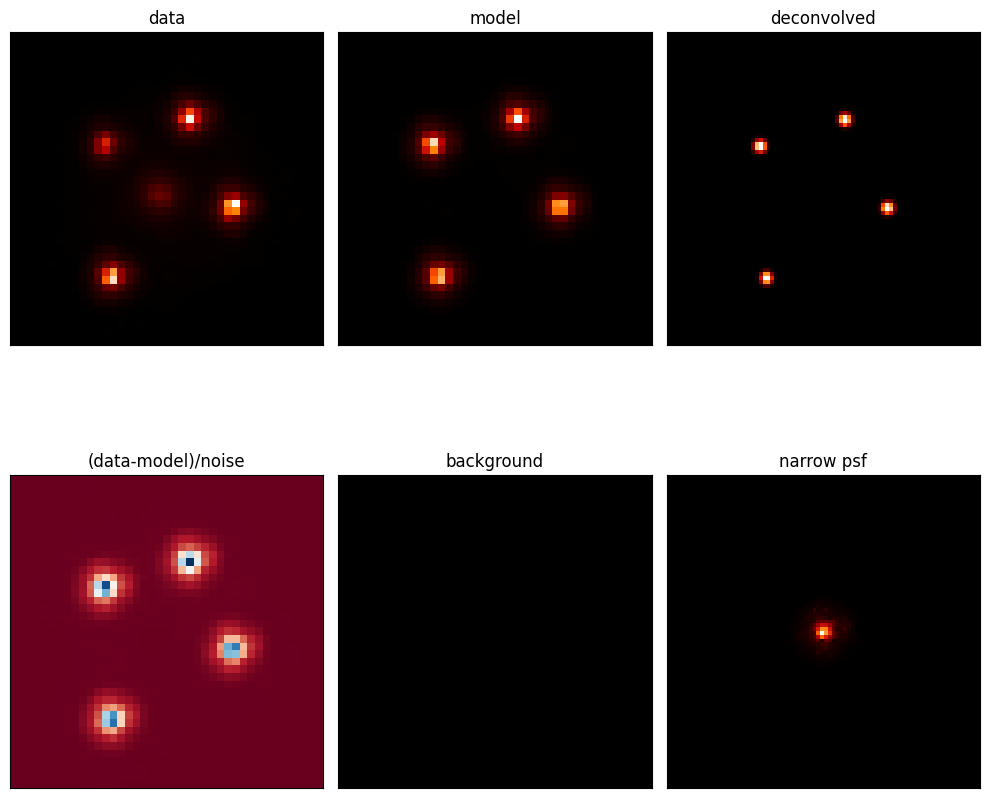

In [72]:
view_deconv_model(model, k_init, data, noisemaps**2, figsize=(10,10))

In [73]:
 # the params needs the initial guess, fixed params and boundaries:
params = ParametersDeconv(k_init, k_fixed, k_up, k_down)
# the loss needs to see our data, noisemaps, model, and the params class:
loss = Loss(data, model, params, noisemaps**2)
# now we can make an optimizer!
optim = Optimizer(loss, params, method='l-bfgs-b')

In [74]:
# optimize (this returns some metrics, but we don't need them here.)
optim.minimize(maxiter=70)
# the best fit is automatically given to the params:
k_optim = params.best_fit_values(as_kwargs=True)

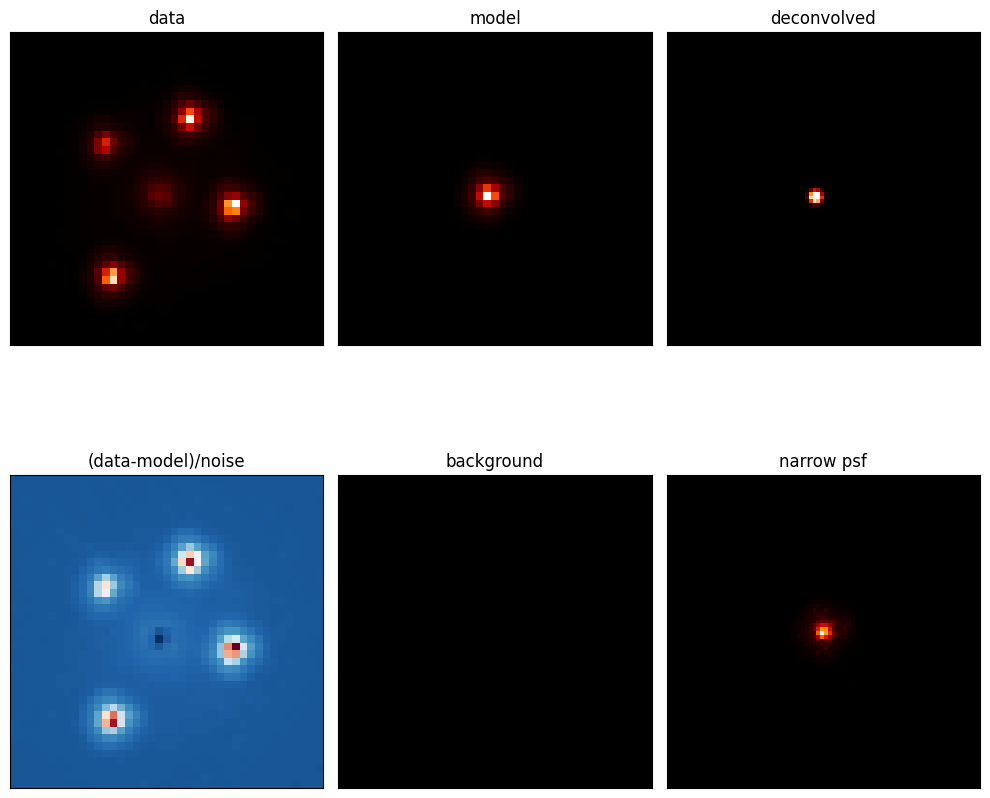

In [75]:
view_deconv_model(model, k_optim, data, noisemaps**2, figsize=(10,10))

In [76]:
 # remove the background fixing:
del k_fixed['kwargs_background']['h']
# calculate the propagation of the noise:
W = propagate_noise(model, noisemaps, k_init, upsampling_factor=2)[0]

In [77]:
# start from our optimized params of before
params = ParametersDeconv(k_optim, k_fixed, k_up, k_down)
# this time we provide the noise scaling to the loss
loss = Loss(data, model, params, noisemaps**2, W=W)
# new optimizer!
optim = Optimizer(loss, params, method='l-bfgs-b')
# let's go directly:
optim.minimize(maxiter=30)
k_optim_with_background = params.best_fit_values(as_kwargs=True).copy()

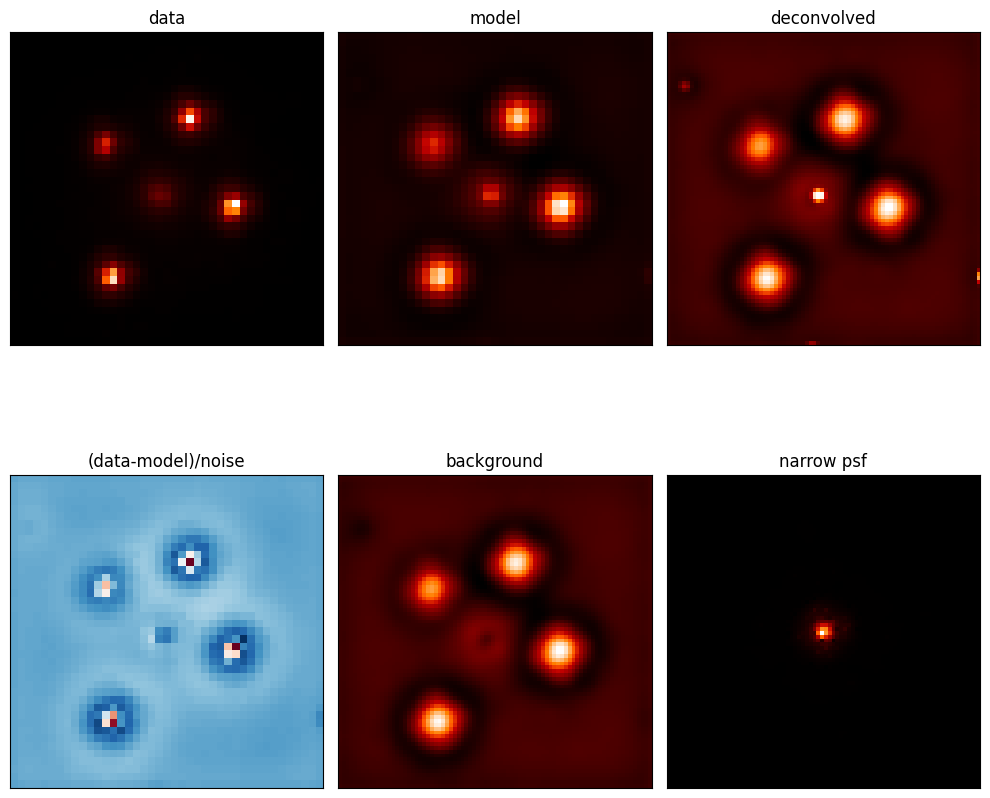

In [78]:
view_deconv_model(model, k_optim_with_background, data, noisemaps**2, figsize=(10,10))